# Quick checks in gene expression etc

In [13]:
here::i_am("rna_atac/differential/RNA.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))


BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code



In [2]:
args = list()

# Metadata
args$metadata = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated.txt.gz')

# RNA_sce
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')

args$logFC_thr = 0.25
args$FDR_thr = 0.05

# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/differential/markers/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [3]:
# Load meta
meta = fread(args$metadata)

#### Load Data

In [4]:
# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

In [5]:
# Prepare mofa umap
umap.dt = meta[,c('cell', 'UMAP1', 'UMAP2', 'genotype')] %>% 
    .[match(colnames(rna.sce), cell),] %>%
    .[,genotype:=gsub('KO', 'Eomes KD', genotype)] %>%
    .[,genotype:=factor(genotype, levels=c('WT', 'Eomes KD'))]

In [6]:
summary(umap.dt$cell == colnames(rna.sce))

   Mode    TRUE 
logical   31596 

In [7]:
head(umap.dt)

cell,UMAP1,UMAP2,genotype
<chr>,<dbl>,<dbl>,<fct>
1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1,-6.742873,-4.051344,WT
1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1,-5.456130,-2.490946,WT
1A_Eo_DEG_G9_day3#AAACATGCAAGTAAGC-1,-6.348085,-4.264254,WT
1A_Eo_DEG_G9_day3#AAACATGCAATATACC-1,-6.044776,-2.846936,WT
1A_Eo_DEG_G9_day3#AAACATGCAATCCTGA-1,-4.960897,-3.201840,WT
1A_Eo_DEG_G9_day3#AAACATGCACTTAGGC-1,-5.634477,-2.450560,WT


In [8]:
options(repr.plot.width=12, repr.plot.height=4)

plot_gene = function(gene, order=F, size=1){
    if(order == TRUE){
        cell_order = colnames(rna.sce[,order(logcounts(rna.sce[gene,])[1,])])
        umap.dt_i = umap.dt[match(cell_order, cell),]
        rna.sce_i = rna.sce[, cell_order]
    }else{ 
        umap.dt_i = umap.dt
        rna.sce_i = rna.sce
    }
    ggplot(umap.dt_i, aes(UMAP1, UMAP2, col=as.vector(logcounts(rna.sce_i[gene,])))) + 
        geom_point(size=size) + 
        scale_color_gradientn(colours = rev(rainbow(3)), name = gene) +
        facet_wrap(~genotype) + 
        ggtitle(gene) + 
        theme_void() + 
        theme(legend.position = 'none',
              strip.text = element_text(size=15),
              plot.title = element_text(size=15, hjust=0.5),
              plot.background = element_rect(color='black')) 
}

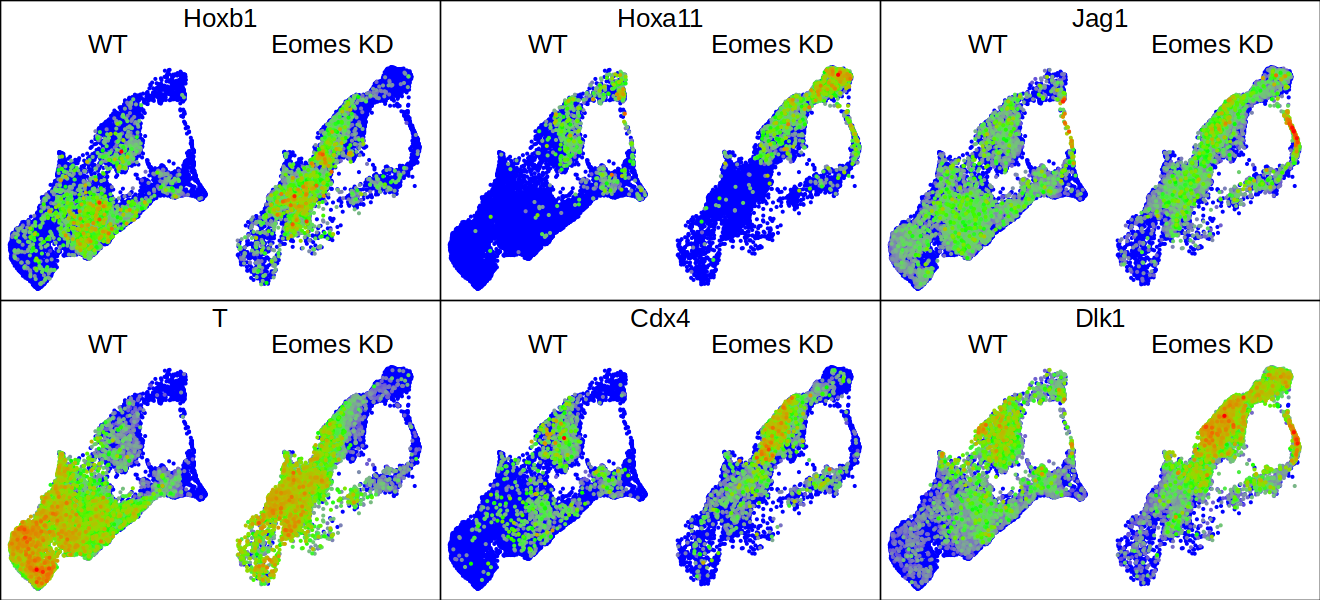

In [47]:
genes = c('Hoxb1', 'Hoxa11', 'Jag1',
          'T', 'Cdx4', 'Dlk1')
p = mclapply(genes, plot_gene, order=TRUE, size=0.1, mc.cores=8)
options(repr.plot.width=11, repr.plot.height=5)
cowplot::plot_grid(plotlist=p, ncol=3)

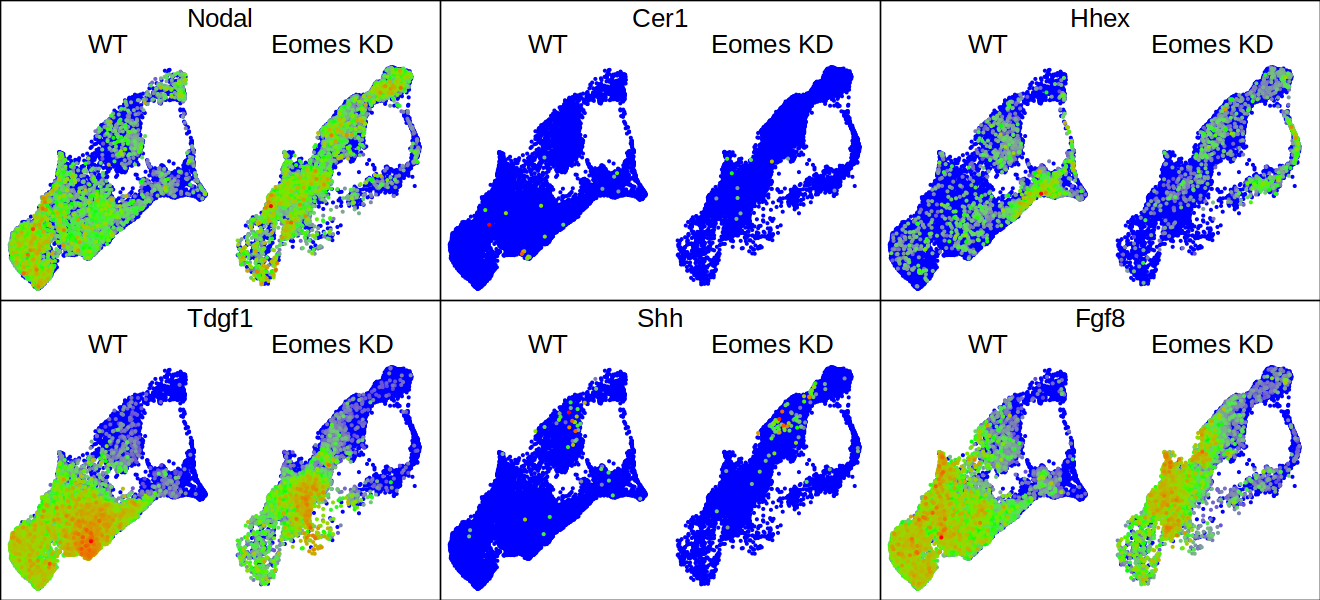

In [11]:
genes = c('Nodal', 'Cer1', 'Hhex', 'Tdgf1', 'Shh', 'Fgf8')
p = mclapply(genes, plot_gene, order=TRUE, size=0.1, mc.cores=8)
options(repr.plot.width=11, repr.plot.height=5)
cowplot::plot_grid(plotlist=p, ncol=3)

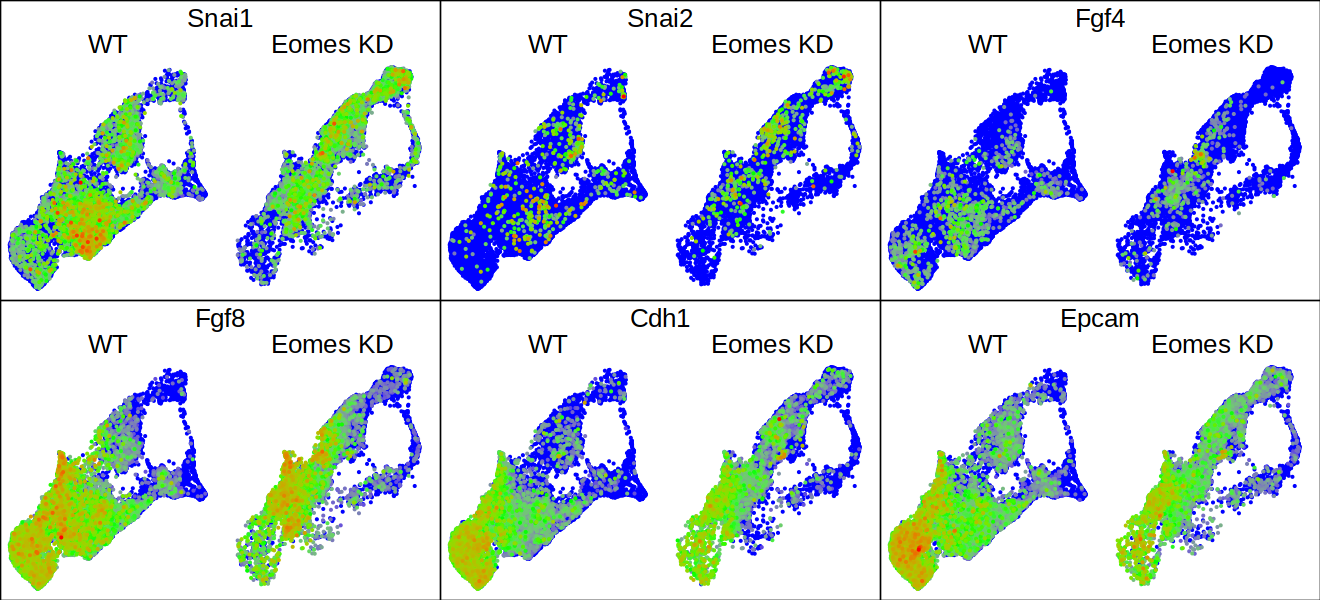

In [15]:
genes = c('Snai1', 'Snai2', 'Fgf4', 'Fgf8', 'Cdh1', 'Epcam')
p = mclapply(genes, plot_gene, order=TRUE, size=0.1, mc.cores=8)
options(repr.plot.width=11, repr.plot.height=5)
cowplot::plot_grid(plotlist=p, ncol=3)

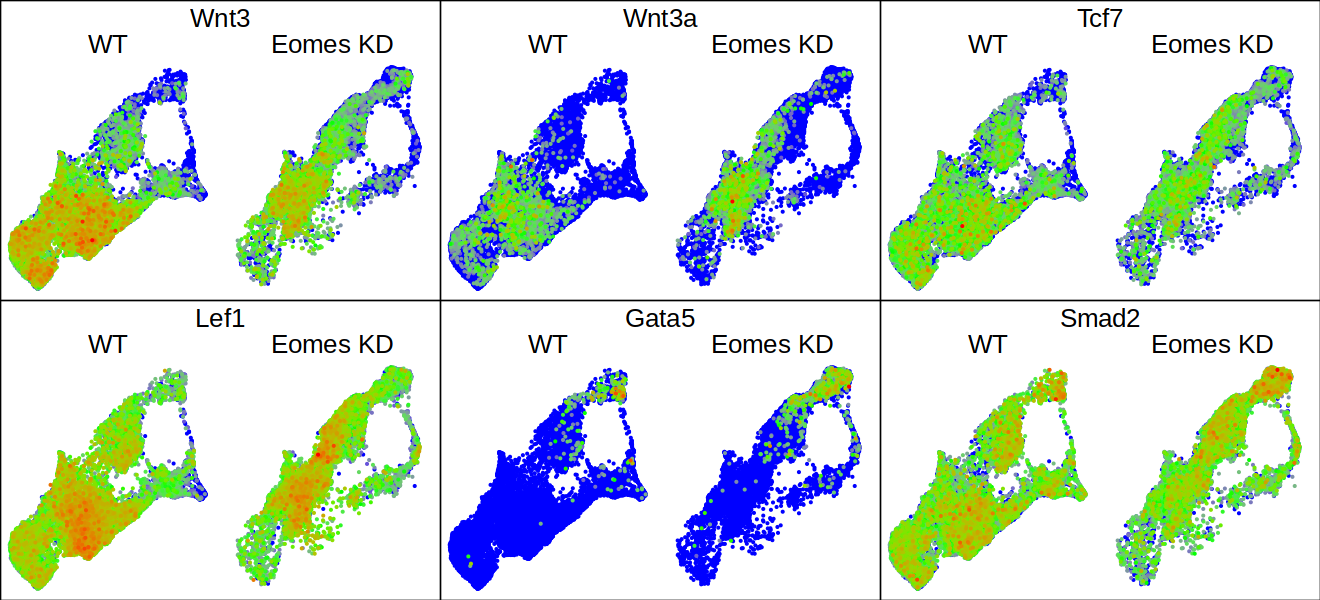

In [17]:
genes = c('Wnt3', 'Wnt3a', 'Tcf7', 'Lef1', 'Gata5', 'Smad2')
p = mclapply(genes, plot_gene, order=TRUE, size=0.1, mc.cores=8)
options(repr.plot.width=11, repr.plot.height=5)
cowplot::plot_grid(plotlist=p, ncol=3)

In [9]:
markers = fread(sprintf('%s/markers_RNA.txt.gz', file.path(io$basedir, 'results/rna_atac/celltype_markers/')))

In [10]:
top_markers = markers %>%
    group_by(cluster) %>%
    slice_max(n = 5, order_by = avg_log2FC)

In [11]:
plot_gene = function(gene, order=F, size=1){
    if(order == TRUE){
        cell_order = colnames(rna.sce[,order(logcounts(rna.sce[gene,])[1,])])
        umap.dt_i = umap.dt[match(cell_order, cell),]
        rna.sce_i = rna.sce[, cell_order]
    }else{ 
        umap.dt_i = umap.dt
        rna.sce_i = rna.sce
    }
    ggplot(umap.dt_i, aes(UMAP1, UMAP2, col=as.vector(logcounts(rna.sce_i[gene,])))) + 
        geom_point(size=size) + 
        scale_color_gradientn(colours = rev(rainbow(3)), name = gene) +
        ggtitle(gene) + 
        theme_void() + 
        theme(legend.position="none",
              plot.title = element_text(size=15, hjust=0.5))
}

In [10]:
genes = c('Pou5f1', 'Eomes', 'Lhx1', 'Dlk1', 'Tbx4', 'Kdr', 'Fli1', 'Cdh5')
p = mclapply(genes, plot_gene, order=TRUE, size=0.2, mc.cores=1)

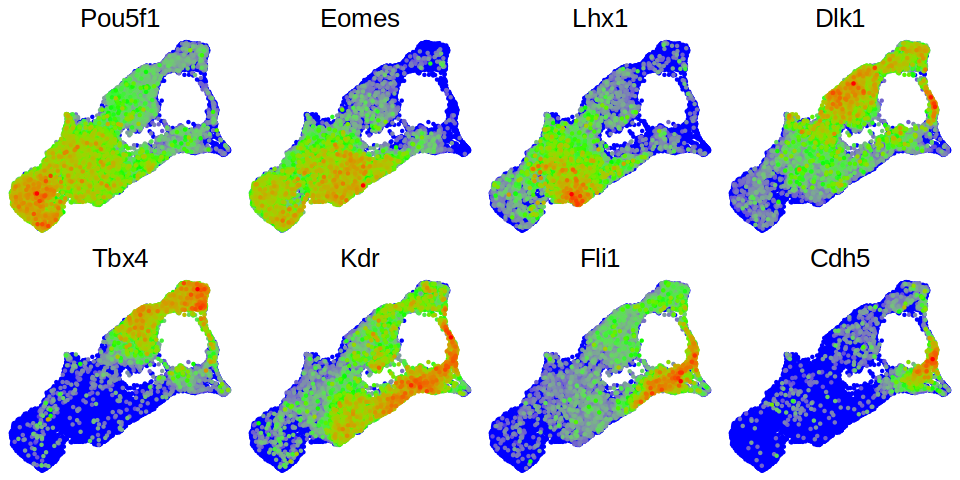

In [12]:
options(repr.plot.width=8, repr.plot.height=4)
cowplot::plot_grid(plotlist=p, ncol=4)

In [48]:
suppressPackageStartupMessages(library(ArchR))
args$archr_directory = file.path(io$basedir, 'processed/atac/archR')

# Load ArchR
ArchRProject <- loadArchRProject(args$archr_directory)


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

In [49]:
getAvailableMatrices(ArchRProject)

[1] "DeviationMatrix_CISBP"   "DeviationMatrix_JASPAR" 
 [3] "GeneScoreMatrix_TSS"     "GeneScoreMatrix_distal" 
 [5] "MarkerPeaksMatrix"       "PeakMatrix"             
 [7] "PeakMatrix_atlas"        "TileMatrix"             
 [9] "silicoChIP_CISBPMatrix"  "silicoChIP_JASPARMatrix"

In [50]:
silicoChip = getMatrixFromProject(ArchRProject, 'silicoChIP_CISBPMatrix')

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-3152f33737fbb9-Date-2024-02-20_Time-16-26-20.log
If there is an issue, please report to github with logFile!

2024-02-20 16:26:36 : Organizing colData, 0.275 mins elapsed.

2024-02-20 16:26:37 : Organizing rowData, 0.286 mins elapsed.

2024-02-20 16:26:37 : Organizing rowRanges, 0.286 mins elapsed.

2024-02-20 16:26:37 : Organizing Assays (1 of 2), 0.286 mins elapsed.

2024-02-20 16:26:38 : Organizing Assays (2 of 2), 0.307 mins elapsed.

2024-02-20 16:26:40 : Constructing SummarizedExperiment, 0.329 mins elapsed.

2024-02-20 16:26:41 : Finished Matrix Creation, 0.344 mins elapsed.



In [51]:
silicoChip = silicoChip[,match(colnames(rna.sce), colnames(silicoChip))]

In [52]:
options(repr.plot.width=12, repr.plot.height=4)

plot_chromvar = function(gene, order=F, size=1){
    tmp = umap.dt %>% copy() %>%
        .[,chromvar := as.vector(silicoChip@assays@data$z[gene,])]
    if(order == TRUE){
        tmp = tmp[order(abs(chromvar))]
    }
    ggplot(tmp, aes(UMAP1, UMAP2, col=chromvar)) + 
        geom_point(size=size) + 
        # scale_color_gradientn(colours = colorRampPalette(c("orange", "grey90", "darkblue"))(100), name = gene) +
        scale_color_gradientn(colours = colorRampPalette(c("darkblue", "grey90", "orange", "darkred"))(100), name = gene) +
        ggtitle(gene) + 
        theme_void() + 
        theme(legend.position="none",
              plot.title = element_text(size=15, hjust=0.5))
}

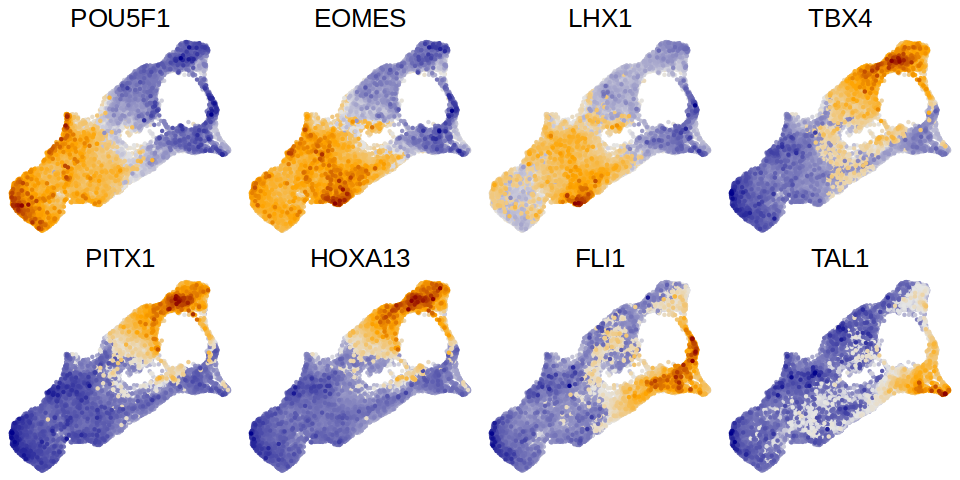

In [21]:
genes = c('POU5F1', 'EOMES', 'LHX1', 'TBX4', 'PITX1', 'HOXA13', 'FLI1', 'TAL1')
p = mclapply(genes, plot_chromvar, order=TRUE, size=0.2, mc.cores=1)
options(repr.plot.width=8, repr.plot.height=4)
cowplot::plot_grid(plotlist=p, ncol=4)

In [53]:
options(repr.plot.width=12, repr.plot.height=4)

plot_chromvar = function(gene, order=F, size=1){
    tmp = umap.dt %>% copy() %>%
        .[,chromvar := as.vector(silicoChip@assays@data$z[gene,])]
    if(order == TRUE){
        tmp = tmp[order(abs(chromvar))]
    }
    
    ggplot(tmp, aes(UMAP1, UMAP2, col=chromvar)) + 
        geom_point(size=size) + 
        # scale_color_gradientn(colours = colorRampPalette(c("orange", "grey90", "darkblue"))(100), name = gene) +
        scale_color_gradientn(colours = colorRampPalette(c("darkblue", "grey90", "orange", "darkred"))(100), name = gene) +
        facet_wrap(~genotype) + 
        ggtitle(gene) + 
        theme_void() + 
        theme(legend.position = 'none',
              strip.text = element_text(size=15),
              plot.title = element_text(size=15, hjust=0.5),
              plot.background = element_rect(color='black')) 
}

In [55]:
silicoChip

class: SummarizedExperiment 
dim: 621 31596 
metadata(0):
assays(2): deviations z
rownames(621): AHRR AIRE ... ZKSCAN3 ZSCAN10
rowData names(2): idx name
colnames(31596): 1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1
  1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1 ...
  rv_eo_deg_day4_dtag#TTTGTGTTCATTTGTC-1
  rv_eo_deg_day4_dtag#TTTGTTGGTACTTAGG-1
colData names(39): BlacklistRatio nDiFrags ... FRIP replicate

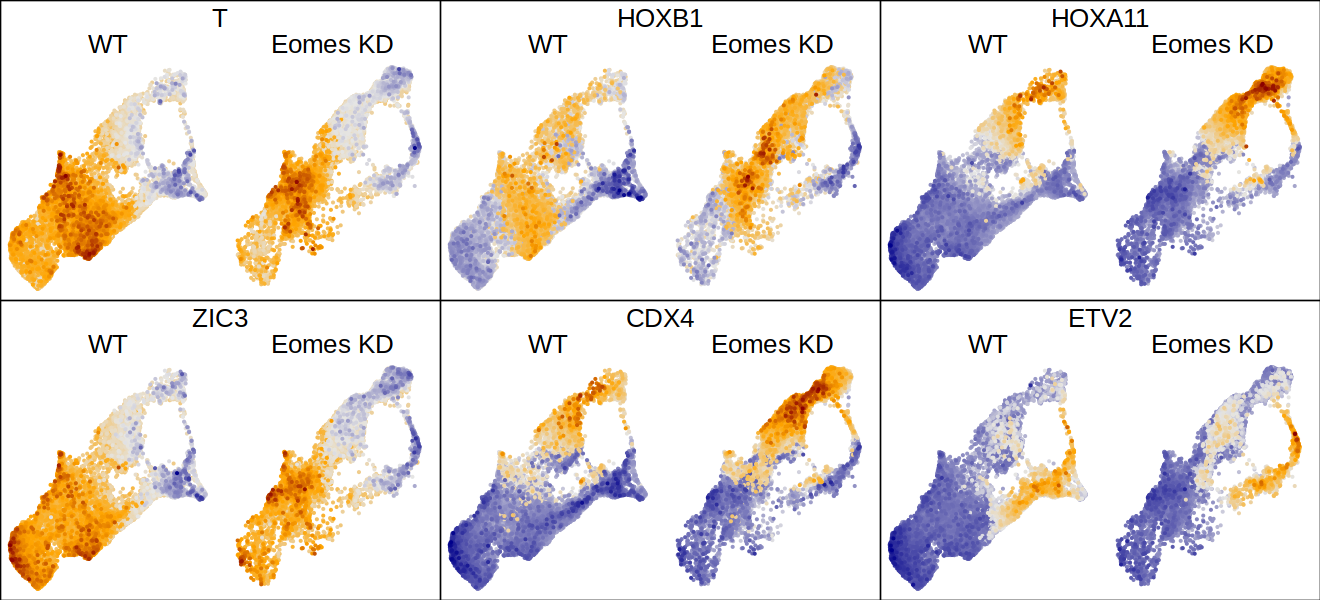

In [58]:
genes = c('T', 'HOXB1', 'HOXA11',
          'ZIC3', 'CDX4', 'ETV2')
p = mclapply(genes, plot_chromvar, order=TRUE, size=0.1, mc.cores=1)
options(repr.plot.width=11, repr.plot.height=5)
cowplot::plot_grid(plotlist=p, ncol=3)